# Introduction to Machine Learning and Neural Networks

Author: Dr. Julie Butler

Date Created: June 1, 2026

Last Modified: June 4, 2026

## Introduction

## A Demonstration

## Coding a Neural Network with Python and Scikit-Learn

### Library Imports

In [208]:
#############
## IMPORTS ##
#############
# KaggleHub allows us to easily access datasets from Kaggle
import kagglehub
# Pandas allows us to read in and manipulate data
import pandas as pd
# MLPClassifier will be our neural network model, from the library scikit-learn
from sklearn.neural_network import MLPClassifier
# accuracy_score will allow us to evaluate our model's performance
from sklearn.metrics import accuracy_score
# ConfusionMatrixDisplay will allow us to visualize our model's performance
from sklearn.metrics import ConfusionMatrixDisplay
# train_test_split will allow us to split our data into training and testing sets
from sklearn.model_selection import train_test_split
# LabelEncoder will allow us to convert categorical variables into numerical variables
from sklearn.preprocessing import LabelEncoder
# StandardScaler will allow us to standardize our data
from sklearn.preprocessing import StandardScaler
# Seaborn will allow us to visualize our data
import seaborn as sns

### Import and Clean the Data Set

In [185]:
###################
## LOAD THE DATA ##
####################

# Download the Titanic dataset from Kaggle and get the address on the computer here the file is stored
path = kagglehub.dataset_download("yasserh/titanic-dataset")
print(path)

# Import the dataset using pandas and take a look at the first few rows
titanic_data = pd.read_csv(path + "/Titanic-Dataset.csv")
titanic_data.head()

/Users/juliebutler/.cache/kagglehub/datasets/yasserh/titanic-dataset/versions/1


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [186]:
# Take a look at the last few rows of the dataset as well
titanic_data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [187]:
# Take a look at the data types of each column and how many non-null values there are.
# Note that machine learning models can only work with numerical data (int64, float64),
#  so we will need to convert the categorical variables (object) into numerical variables 
# before we can use them in our model. Additionally, we will need to handle the missing values 
# in the dataset before we can use it in our model.
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [188]:
# Drop the columns that we won't be using in our model. These columns are not useful for predicting 
# survival and will only add noise to our model.
titanic_data = titanic_data.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [189]:
# Drop the rows with missing values. This is a simple way to handle missing values, but it 
# can lead to loss of data and potentially bias our model if the missing values are not random. 
# In a real project, we would want to explore other methods of handling missing values.
titanic_data = titanic_data.dropna()

In [190]:
# Take a look at the data types of each column and how many non-null values there are again, 
# after dropping the columns and rows with missing values.
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    object 
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  712 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 50.1+ KB


In [191]:
# Convert the categorical variables into numerical variables using LabelEncoder. 
# This will allow us to use these variables in our model.

# First we will convert the "Sex" column, which has two categories: "male" and "female".
le_sex = LabelEncoder()
titanic_data["Sex"] = le_sex.fit_transform(titanic_data["Sex"])
# Now the "Sex" column has been converted to numerical values, where "male" is represented as 1 and 
# "female" is represented as 0.
print("Original classes:", le_sex.classes_)
print("Transformed classes:", le_sex.transform(le_sex.classes_))
print()
# Next we will convert the "Embarked" column, which has three categories: "C", "Q", and "S".
le_embarked = LabelEncoder()
titanic_data["Embarked"] = le_embarked.fit_transform(titanic_data["Embarked"])
# Now the "Embarked" column has been converted to numerical values, where "C" is represented as 0, 
# "Q" is represented as 1, and "S" is represented as 2.
print("Original classes:", le_embarked.classes_)
print("Transformed classes:", le_embarked.transform(le_embarked.classes_))

Original classes: ['female' 'male']
Transformed classes: [0 1]

Original classes: ['C' 'Q' 'S']
Transformed classes: [0 1 2]


In [192]:
# Final check to make sure that there are no null values and that all the data is in the correct format (numerical).
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    int64  
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  712 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 50.1 KB


### Visualize the Data Set

<Axes: xlabel='Survived', ylabel='count'>

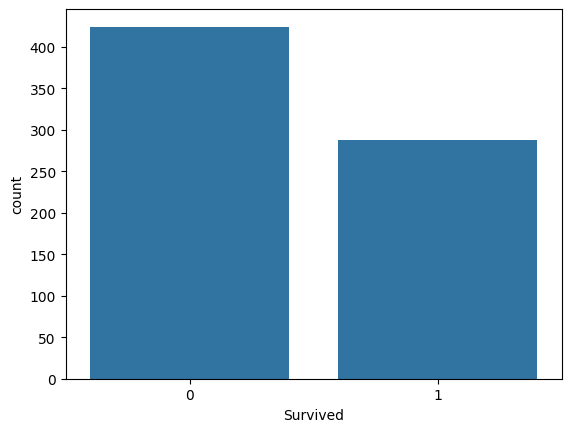

In [193]:
# Take a look at the distribution of the target variable "Survived" to see how many people survived 
# and how many people did not survive.
# 0 represents people who did not survive, and 1 represents people who survived.
sns.countplot(x="Survived", data=titanic_data)

<Axes: xlabel='Pclass', ylabel='Survived'>

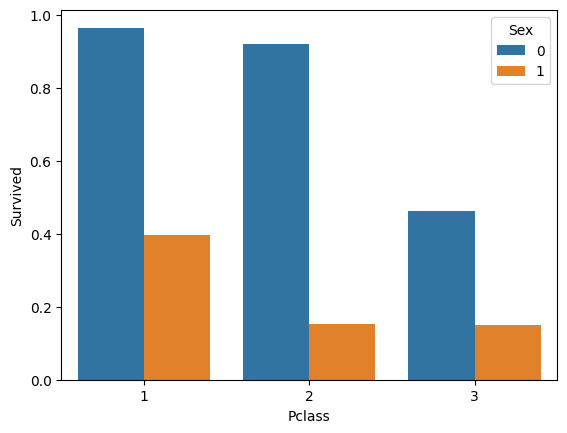

In [194]:
# Take a look at the distribution of the target variable "Survived" based on the "Pclass" 
# and "Sex" columns. Remember that "Pclass" represents the passenger class (1st, 2nd, 
# or 3rd class), and "Sex" is 0 for female and 1 for male. The higher the bar, the higher 
# the survival rate for that group of people.
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=titanic_data, errorbar=None)

<Axes: xlabel='Embarked', ylabel='Survived'>

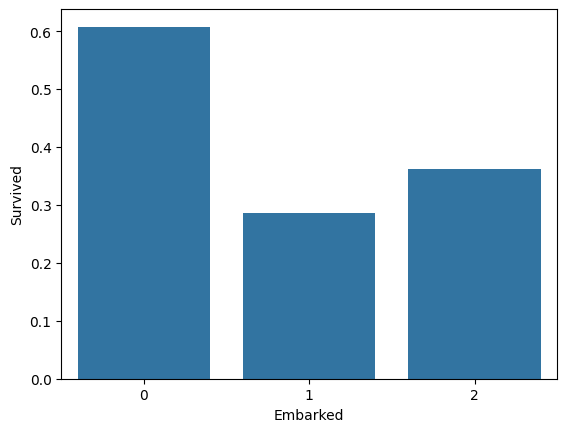

In [195]:
# Take a look at the distribution of the target variable "Survived" based on 
# the "Embarked" column. Remember that "Embarked" is 0 for Cherbourg, 1 for 
# Queenstown, and 2 for Southampton.
sns.barplot(x="Embarked", y="Survived", errorbar=None, data=titanic_data)

<Axes: xlabel='Survived', ylabel='Fare'>

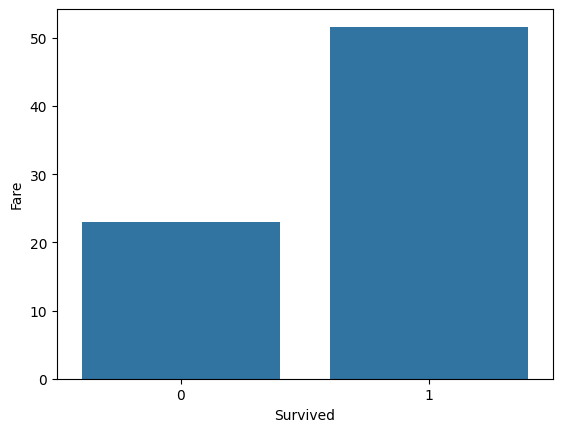

In [196]:
# Take a look at the distribution of the target variable "Survived" based on the average 
# "Fare" column.
sns.barplot(x="Survived", y="Fare", errorbar=None, data=titanic_data)

<Axes: xlabel='Survived', ylabel='Age'>

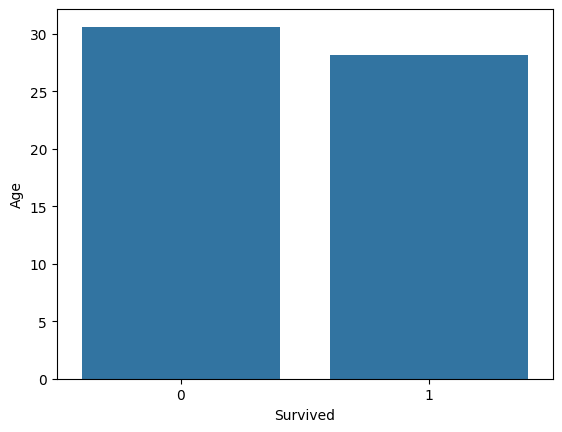

In [ ]:
# Now let's take a look at the distribution of the target variable "Survived" based on the average 
# "Age" column. This will allow us to see if there is a relationship between age and survival rate.
sns.barplot(x="Survived", y="Age", errorbar=None, data=titanic_data)

<Axes: xlabel='Parch', ylabel='Survived'>

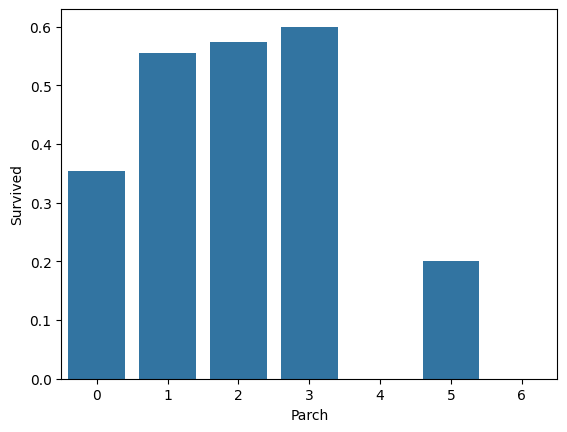

In [ ]:
# Finally, let's take a look at the distribution of the target variable "Survived" based on the 
# number of parents/children aboard the Titanic, which is represented by the "Parch" column. 
# This will allow us to see if there is a relationship between having parents/children aboard and 
# survival rate.
sns.barplot(x="Parch", y="Survived", errorbar=None, data=titanic_data)

<Axes: xlabel='SibSp', ylabel='Survived'>

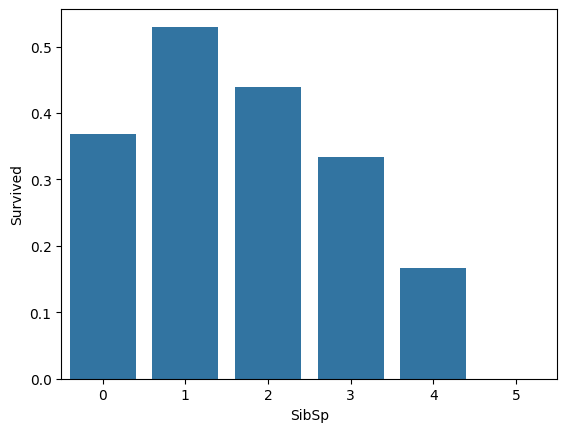

In [ ]:
# Finally, let's take a look at the distribution of the target variable "Survived" based on the
# number of siblings/spouses aboard the Titanic, which is represented by the "SibSp" column. 
# This will allow us to see if there is a relationship between having siblings/spouses aboard and
# survival rate.
sns.barplot(x="SibSp", y="Survived", errorbar=None, data=titanic_data)

### First Attempt at a Neural Network

In [ ]:
# First we will use the "Age" column as our feature (X) and the "Survived" column as our target variable (y).
# The X data is the input to the neural network, and the y data is the output that we want the neural network
# to predict. In this case, we want the neural network to predict whether a person survived (1) or did not survive (0).
X = titanic_data[["Age"]]
y = titanic_data["Survived"]

# Split the data into training and testing sets. The training set will be used to train the model, and the testing set 
# will be used to evaluate the model's performance. We will use 80% of the data for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Now we will create an instance of the MLPClassifier, which is a type of neural network model. We will specify the
# architecture of the neural network (hidden_layer_sizes), the maximum number of iterations for training (max_iter), 
# and the activation function to use (activation). The hidden_layer_sizes parameter specifies the number of hidden layers 
# and the number of neurons in each hidden layer. In this case, we are using one hidden layer with 10 neurons. We are using 
# the ReLU activation function, which is a common choice for hidden layers in neural networks. Finally, we will train the network
# using 300 iterations.
mlp = MLPClassifier(hidden_layer_sizes=(10), max_iter=300, activation="relu")

# Train the model using both the X_train and y_train data. The neural network will learn the relationship between the input data 
# (X_train) and the output data (y_train) during this step.
mlp.fit(X_train, y_train)

# After training the model, we can use it to make predictions on the testing data (X_test). The model will output predicted values 
# for the target variable (y_pred) based on the input data (X_test).
y_pred = mlp.predict(X_test)

# Print the accuracy of the model, which is the percentage of correct predictions out of all predictions made. The accuracy_score function
# compares the true values (y_test) with the predicted values (y_pred) and calculates the accuracy. We multiply by 100 to convert it to a 
# percentage and add a "%" sign for readability.
print("Accuracy:", accuracy_score(y_test, y_pred)*100, "%")


ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.8181818181818182


/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overfl

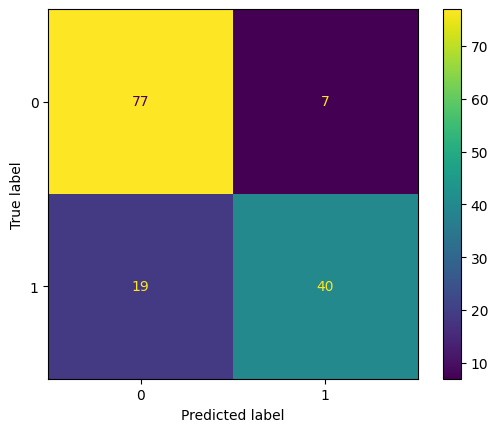

In [201]:
X = titanic_data.drop(columns=["Survived"])
y = titanic_data["Survived"]

Z = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.2)

mlp2 = MLPClassifier(hidden_layer_sizes=(10), max_iter=300, activation="relu")
mlp2.fit(X_train, y_train)
y_pred = mlp2.predict(X_test)

print(accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

### Attempts to Improve Accuracy

#### "Pre-Process" the Data Set

0.8111888111888111


/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overfl

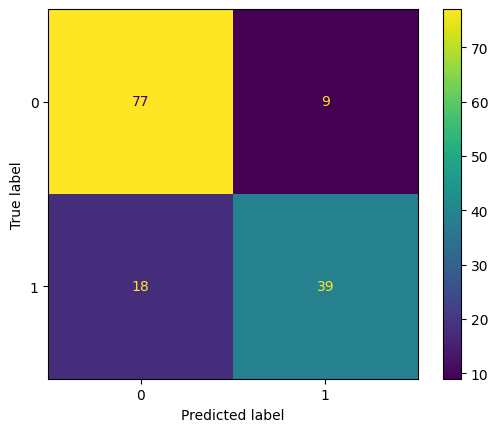

In [209]:
X = titanic_data.drop(columns=["Survived"])
y = titanic_data["Survived"]

Z = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.2)

mlp2 = MLPClassifier(hidden_layer_sizes=(10), max_iter=300, activation="relu")
mlp2.fit(X_train, y_train)
y_pred = mlp2.predict(X_test)

print(accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

#### Make the Network Deeper

/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.8111888111888111


/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


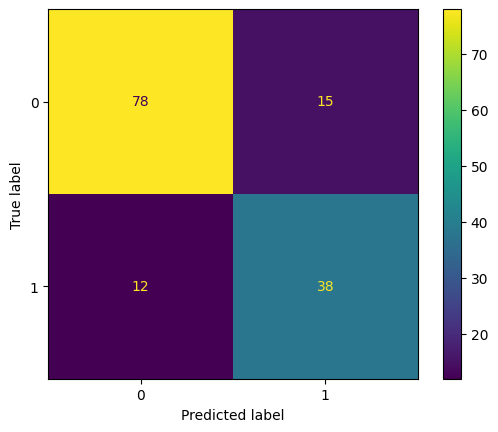

In [ ]:
X = titanic_data.drop(columns=["Survived"])
y = titanic_data["Survived"]

Z = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.2)

mlp2 = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=300, activation="relu")
mlp2.fit(X_train, y_train)
y_pred = mlp2.predict(X_test)

print(accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

### Or Make the Network Wider

/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.7762237762237763


/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


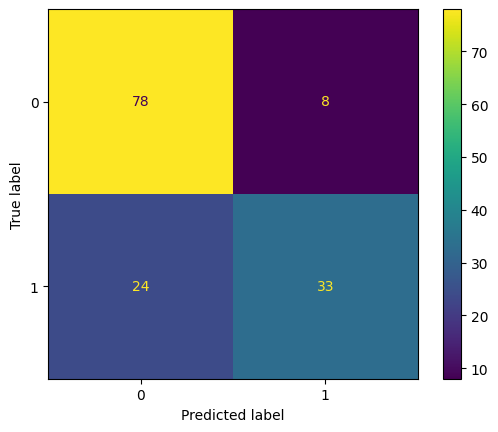

In [210]:
X = titanic_data.drop(columns=["Survived"])
y = titanic_data["Survived"]

Z = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.2)

mlp2 = MLPClassifier(hidden_layer_sizes=(25, 10), max_iter=300, activation="relu")
mlp2.fit(X_train, y_train)
y_pred = mlp2.predict(X_test)

print(accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

#### Change the Activation Function and Iterations

/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


0.8041958041958042


/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (450) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/juliebutler/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


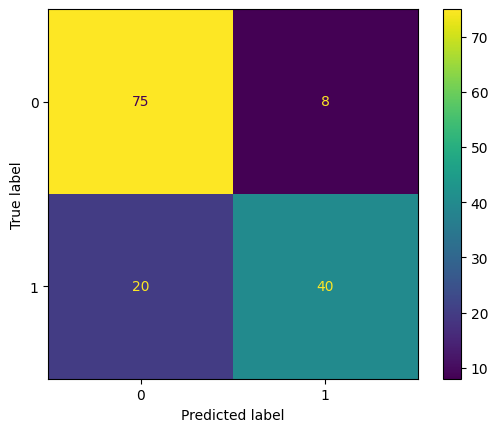

In [205]:
X = titanic_data.drop(columns=["Survived"])
y = titanic_data["Survived"]

Z = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.2)

mlp2 = MLPClassifier(hidden_layer_sizes=(25, 25), max_iter=450, activation="tanh")
mlp2.fit(X_train, y_train)
y_pred = mlp2.predict(X_test)

print(accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)